In [1]:
import sys
import os

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q
    os.kill(os.getpid(), 9)  # force runtime restart

# Курс по прогнозированию временных рядов
# Неделя 3.
# Семейство ETS в StatsForecast


## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 0 | Какие ETS-модели есть в `statsforecast` и какие у них гиперпараметры |
| 1 | Как их обучать и что доступно после обучения (аналог `.states`/`summary()`) |
| 2 | Доверительные интервалы |
| 3 | Чем это принципиально отличается от `statsmodels` и что даёт масштаб |


---
# Импорты и данные

In [2]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# --- statsforecast: модели, оркестратор, конформные интервалы ---
import statsforecast

# --- для честного сравнения с "академической" реализацией ---
import statsmodels

# --- utilsforecast: графики и метрики качества ---
import utilsforecast
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoETS,
    Holt,
    HoltWinters,
    SimpleExponentialSmoothingOptimized,
)
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mape, rmse
from utilsforecast.plotting import plot_series

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

print("statsforecast: ", statsforecast.__version__)
print("utilsforecast: ", utilsforecast.__version__)
print("statsmodels:   ", statsmodels.__version__)
print("pandas:        ", pd.__version__)

statsforecast:  2.1.1
utilsforecast:  0.2.16
statsmodels:    0.14.6
pandas:         2.3.3


Сквозной пример — классический `AirPassengers` (число пассажиров авиалиний,
1949–1960, помесячно). Как и на первом занятии, приводим данные к длинному формату
`unique_id / ds / y`, который ожидает `StatsForecast`.

Всего наблюдений: 144 | train: 132 | test: 12


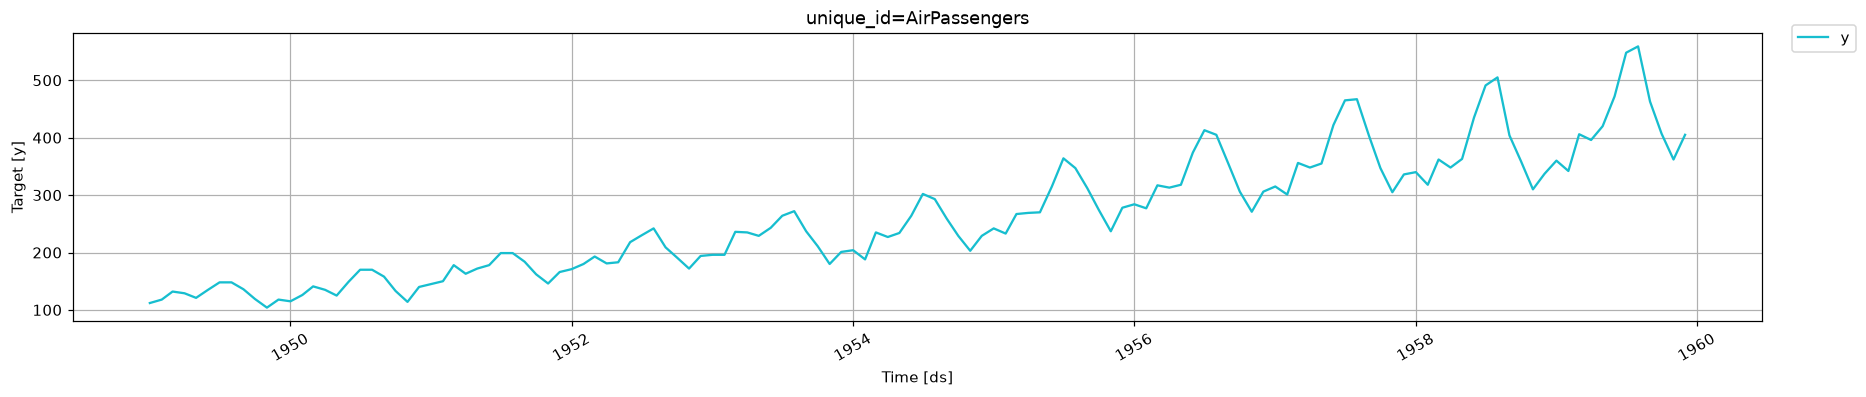

In [3]:
raw = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/data/airline-passengers.csv",
    parse_dates=["Month"],
)

air = raw.rename(columns={"Month": "ds", "Passengers": "y"}).assign(unique_id="AirPassengers")[
    ["unique_id", "ds", "y"]
]

h = 12  # горизонт прогноза — год вперёд
air_train, air_test = air.iloc[:-h].copy(), air.iloc[-h:].copy()

print("Всего наблюдений:", len(air), "| train:", len(air_train), "| test:", len(air_test))
plot_series(air_train, forecasts_df=None)

---
# 0. Каталог ETS-моделей и их гиперпараметры

## 0.1. Нет одного класса `ETS` — есть лестница классов

В `statsmodels` вы задаёте одну модель (`ETSModel(error=..., trend=..., seasonal=...)`)
и сами перебираете спецификации. В `statsforecast` вместо этого — набор готовых
классов, от «всё зафиксировано руками» до «всё подбирается автоматически»:

| Класс | Что фиксировано | Гиперпараметры |
|---|---|---|
| `SimpleExponentialSmoothing(alpha)` | ETS(A,N,N), $\alpha$ задаёте сами | `alpha` |
| `SimpleExponentialSmoothingOptimized()` | ETS(A,N,N), $\alpha$ подбирается | — |
| `SeasonalExponentialSmoothing(alpha, season_length)` | сезонность есть, $\alpha$ фиксирован | `alpha`, `season_length` |
| `SeasonalExponentialSmoothingOptimized(season_length)` | сезонность есть, $\alpha$ подбирается | `season_length` |
| `Holt(season_length, error_type)` | ETS(_,A,N) — тренд без сезонности | `error_type` ('A'/'M'), `season_length` |
| `HoltWinters(season_length, error_type)` | ETS(_,A,A/M) — тренд + сезонность | `error_type`, `season_length` |
| `AutoETS(season_length, model, damped, phi)` | ничего — всё может подбираться | `season_length`, `model`, `damped`, `phi` |


## 0.2. Главный игрок — `AutoETS` и его строка `model`

`AutoETS(season_length=1, model='ZZZ', damped=None, phi=None)` — самый гибкий класс.
Строка `model` — это три буквы: **E**rror, **T**rend, **S**easonality (в этом порядке).
У каждой буквы четыре допустимых значения:

| Значение | Смысл |
|---|---|
| `A` | аддитивная компонента |
| `M` | мультипликативная компонента |
| `N` | компоненты нет (только для Trend/Seasonality) |
| `Z` | «подбери сам» по критерию AICc |

`model='ZZZ'` (значение по умолчанию) — это и есть Auto-ETS в полном смысле: перебор
всех допустимых комбинаций и выбор лучшей по AICc. Можно зафиксировать часть букв,
если вы уже знаете структуру ряда, например `model='AZN'` — «ошибка точно аддитивная,
без сезонности, а тип тренда подбери сам».

In [4]:
ap_auto = AutoETS(season_length=12, model="ZZZ", alias="AutoETS")

sf_demo = StatsForecast(models=[ap_auto], freq="MS", n_jobs=1)
sf_demo.fit(air_train)

chosen = sf_demo.fitted_[0, 0].model_
print("AutoETS(model='ZZZ') на AirPassengers выбрал:", chosen["method"])
print("Компоненты (Error, Trend, Season, Damped):", chosen["components"])

AutoETS(model='ZZZ') на AirPassengers выбрал: ETS(M,N,M)
Компоненты (Error, Trend, Season, Damped): MNMN


1. **`season_length=1` по умолчанию.** Если у вас месячные данные с годовой
   сезонностью, но вы забыли передать `season_length=12`, модель просто не увидит
   сезонность — не будет ошибки, будет тихо неверный результат.
2. **Не все комбинации E/T/S допустимы.** Мультипликативная сезонность с
   аддитивным трендом при отрицательных/нулевых значениях ряда может быть
   численно неустойчива — `AutoETS` сам исключает такие сочетания из перебора,
   не сообщая явно, что́ выбросил.
3. **`damped` работает только при наличии тренда.** `AutoETS(model='ZNN', damped=True)`
   не имеет смысла — демпфировать нечего.
4. **`alias`.** Если в одном `StatsForecast` несколько моделей `AutoETS` с разными
   параметрами, задавайте каждой свой `alias` — иначе все колонки в результате
   назовутся одинаково `AutoETS` и перезатрут друг друга.

---
# 1. Запуск моделей и аналитика обученной модели

## 1.1. Три способа получить прогноз

| Способ | Код | Когда использовать |
|---|---|---|
| `forecast()` | `sf.forecast(df=df, h=12)` | быстро, модели не сохраняются в памяти — стандарт для тысяч рядов |
| `fit()` → `predict()` | `sf.fit(df)`; `sf.predict(h=12)` | нужно заглянуть внутрь обученных моделей или предсказывать много раз |
| `cross_validation()` | `sf.cross_validation(df=df, h=12, n_windows=3)` | честная оценка качества на нескольких окнах (тема отдельного занятия) |

Ниже нам нужны обученные модели, поэтому используем `fit`/`predict`.

In [5]:
models = [
    SimpleExponentialSmoothingOptimized(alias="SES"),
    Holt(season_length=12, alias="Holt"),
    HoltWinters(season_length=12, alias="HoltWinters"),
    AutoETS(season_length=12, alias="AutoETS"),
]

sf = StatsForecast(models=models, freq="MS", n_jobs=1)
sf.fit(air_train)

forecast = sf.predict(h=h)
forecast.head()

,unique_id,ds,SES,Holt,HoltWinters,AutoETS
0,AirPassengers,1960-01-01,404.574554,407.222015,409.680145,406.651276
1,AirPassengers,1960-02-01,404.574554,409.448090,390.044067,401.732910
2,AirPassengers,1960-03-01,404.574554,411.674194,448.929810,456.289642
3,AirPassengers,1960-04-01,404.574554,413.900269,435.445007,440.870514
4,AirPassengers,1960-05-01,404.574554,416.126343,454.699951,440.333923


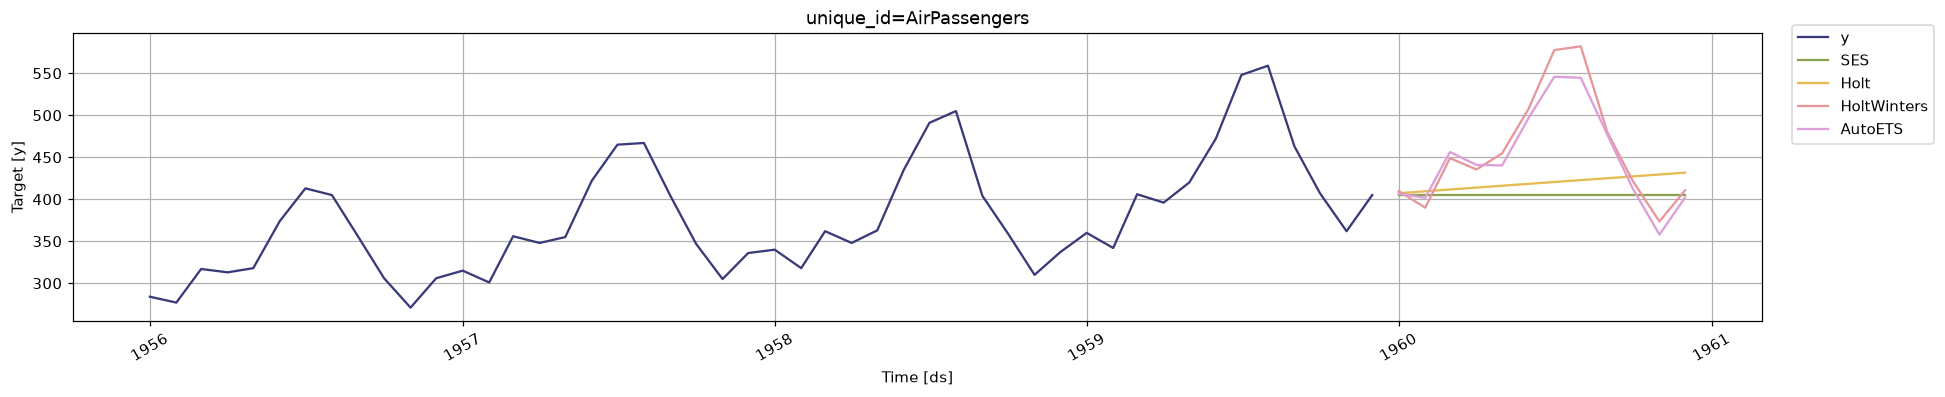

In [6]:
StatsForecast.plot(df=air_train, forecasts_df=forecast, max_insample_length=48)

## 1.2. Что доступно после обучения

У `sf.fitted_` — массив обученных моделей формы `(число рядов, число моделей)`.
Для каждой ячейки `.model_` — это **словарь** (не объект с `summary()`, как в
`statsmodels`!) со всей внутренней информацией об обучении.

In [10]:
m = sf.fitted_[0, 3].model_  # индекс 3 = AutoETS в списке models выше
print("Ключи model_:")
print(sorted(m.keys()))

Ключи model_:
['actual_residuals', 'aic', 'aicc', 'amse', 'bic', 'components', 'distribution', 'fit', 'fitted', 'loglik', 'm', 'method', 'mse', 'n_params', 'nstate', 'par', 'residuals', 'sigma2', 'states']



| Параметр | Категория | Описание |
|---|---|---|
| method | Спецификация | Название и формула выбранной модели (например, ARIMA(1,1,1) или ETS(M,A,N)). |
| m | Спецификация | Период сезонности ряда (например, 7 — недельная, 12 — годовая). |
| n_params | Спецификация | Общее количество оцененных коэффициентов и параметров в модели. |
| par | Спецификация | Финальные численные значения найденных коэффициентов модели. |
| fitted | Результаты | Исторические предсказания модели на обучающей выборке (In-sample прогнозы). |
| actual_residuals | Ошибки ряда | Фактические нескалированные остатки (разница между фактом и fitted). |
| residuals | Ошибки ряда | Стандартизированные (нормализованные) остатки модели для тестов. |
| mse | Метрики качества | Среднеквадратичная ошибка модели на обучающих данных. |
| amse | Метрики качества | Скорректированная среднеквадратичная ошибка (Adjusted MSE). |
| sigma2 | Метрики качества | Оценка дисперсии остатков (ошибки) модели. |
| loglik | Метрики качества | Логарифм функции правдоподобия (Log-Likelihood). Чем выше, тем точнее модель. |
| aic | Критерии отбора | Информационный критерий Акаике. Штрафует за переобучение. Меньше — лучше. |
| aicc | Критерии отбора | Скорректированный критерий Акаике. Применяется для малых выборок. |
| bic | Критерии отбора | Байесовский информационный критерий. Штрафует за лишние параметры жестче, чем AIC. |
| distribution | Пространство состояний | Распределение ошибок (например, нормальное) для построения доверительных интервалов. |
| components | Пространство состояний | Выделенные компоненты временного ряда (тренд, сезонность, уровень). |
| states | Пространство состояний | Векторы или матрицы изменения скрытых состояний модели во времени. |
| nstate | Пространство состояний | Общее количество скрытых состояний системы (актуально для моделей класса ETS). |



In [16]:
m["method"], m["m"], m["n_params"], m["par"]

('ETS(M,N,M)',
 12,
 15,
 array([4.13446528e-01,            nan, 3.05931609e-03,            nan,
        1.29069282e+02, 8.96236155e-01, 7.97949624e-01, 9.19435258e-01,
        1.06378991e+00, 1.21428967e+00, 1.21654739e+00, 1.10765379e+00,
        9.81771292e-01, 9.82968308e-01, 1.01699394e+00, 8.95757962e-01,
        9.06606688e-01]))

In [20]:
m["fitted"]

array([117.01507409, 113.56618355, 131.01800285, 127.02694424,
       127.68701612, 140.93980182, 152.09839357, 150.12480125,
       130.74863577, 114.88278278, 101.18056877, 114.95263529,
       117.54186333, 115.12581572, 135.79875319, 133.33709364,
       133.83360067, 146.87780305, 162.28860039, 165.17621758,
       146.47571124, 130.71557115, 114.26093609, 128.21319284,
       134.58890489, 137.31443562, 161.81044451, 162.85744749,
       162.645136  , 187.91524447, 201.91659202, 200.33486828,
       175.07733245, 154.47709029, 136.75367174, 157.93674273,
       163.08388302, 164.47323692, 193.9746345 , 187.02840479,
       184.26066063, 207.28605095, 232.59110093, 231.09175591,
       206.50305988, 179.33598376, 159.82113313, 185.20566819,
       190.96362616, 190.88695405, 219.0023005 , 218.3713101 ,
       224.92779703, 255.69795663, 275.08961102, 270.05270124,
       237.37923269, 205.02241285, 180.07880752, 202.25264856,
       203.98842083, 201.71208912, 222.48865358, 219.94

In [15]:
m["distribution"], m["components"], m["nstate"]

('normal', 'MNMN', 12)

In [44]:
def ets_report(model_):
    """Собирает человекочитаемый отчёт по обученной ETS-модели statsforecast.

    Возвращает три pandas.Series: параметры сглаживания, начальные состояния
    и информационные критерии — аналог того, что `summary()` печатает в statsmodels.
    """
    _error, trend, season, _damped = model_["components"]

    smoothing_names = ["alpha", "beta", "gamma", "phi"]
    smoothing = pd.Series(model_["par"][:4], index=smoothing_names).dropna()

    state_names = ["level"]
    if trend != "N":
        state_names.append("trend")
    if season != "N":
        state_names += [f"season_lag_{i + 1}" for i in range(model_["m"])]
    init_states = pd.Series(
        model_["par"][4 : 4 + model_["nstate"] + 1], index=state_names, name="init_state"
    )

    criteria = pd.Series({k: model_[k] for k in ["aic", "aicc", "bic", "loglik", "mse", "sigma2"]})
    return smoothing, init_states, criteria


smoothing, init_states, criteria = ets_report(m)
print(f"Выбранная спецификация: {m['method']}\n")
print("Параметры сглаживания:")
print(smoothing.round(4), "\n")
print("Начальные состояния:")
print(init_states, "\n")
print("Информационные критерии:")
print(criteria.round(2))

Выбранная спецификация: ETS(M,N,M)

Параметры сглаживания:
alpha    0.4134
gamma    0.0031
dtype: float64 

Начальные состояния:
level            129.069282
season_lag_1       0.896236
season_lag_2       0.797950
season_lag_3       0.919435
season_lag_4       1.063790
season_lag_5       1.214290
season_lag_6       1.216547
season_lag_7       1.107654
season_lag_8       0.981771
season_lag_9       0.982968
season_lag_10      1.016994
season_lag_11      0.895758
season_lag_12      0.906607
Name: init_state, dtype: float64 

Информационные критерии:
aic       1293.33
aicc      1297.47
bic       1336.57
loglik    -631.66
mse        149.64
sigma2       0.00
dtype: float64


## 1.3. `.states` — как менялось скрытое состояние во времени

Как и в `statsmodels`, `states` — это матрица
`(n + 1) × nstate`: по строке на каждый момент времени плюс начальное состояние,
по столбцу на каждую компоненту (уровень, тренд, сезонные лаги).

In [46]:
m["states"].shape, air_train.shape

((133, 13), (132, 3))

In [48]:
m["states"][0]

array([129.06928179,   0.89623615,   0.79794962,   0.91943526,
         1.06378991,   1.21428967,   1.21654739,   1.10765379,
         0.98177129,   0.98296831,   1.01699394,   0.89575796,
         0.90660669])

In [49]:
init_states

level            129.069282
season_lag_1       0.896236
season_lag_2       0.797950
season_lag_3       0.919435
season_lag_4       1.063790
season_lag_5       1.214290
season_lag_6       1.216547
season_lag_7       1.107654
season_lag_8       0.981771
season_lag_9       0.982968
season_lag_10      1.016994
season_lag_11      0.895758
season_lag_12      0.906607
Name: init_state, dtype: float64

In [50]:
error, trend, season, damped = m["components"]
state_cols = ["level"]
if trend != "N":
    state_cols.append("trend")
if season != "N":
    state_cols += [f"season_lag_{i + 1}" for i in range(m["m"])]

states = pd.DataFrame(m["states"], columns=state_cols)
states.index.name = "t"
states.head()

,level,season_lag_1,season_lag_2,season_lag_3,season_lag_4,season_lag_5,season_lag_6,season_lag_7,season_lag_8,season_lag_9,season_lag_10,season_lag_11,season_lag_12
t,,,,,,,,,,,,,
0,129.069282,0.896236,0.797950,0.919435,1.063790,1.214290,1.216547,1.107654,0.981771,0.982968,1.016994,0.895758,0.906607
1,126.782221,0.906488,0.896236,0.797950,0.919435,1.063790,1.214290,1.216547,1.107654,0.981771,0.982968,1.016994,0.895758
2,128.828695,0.895865,0.906488,0.896236,0.797950,0.919435,1.063790,1.214290,1.216547,1.107654,0.981771,0.982968,1.016994
3,129.227914,1.017017,0.895865,0.906488,0.896236,0.797950,0.919435,1.063790,1.214290,1.216547,1.107654,0.981771,0.982968
4,130.057802,0.983015,1.017017,0.895865,0.906488,0.896236,0.797950,0.919435,1.063790,1.214290,1.216547,1.107654,0.981771


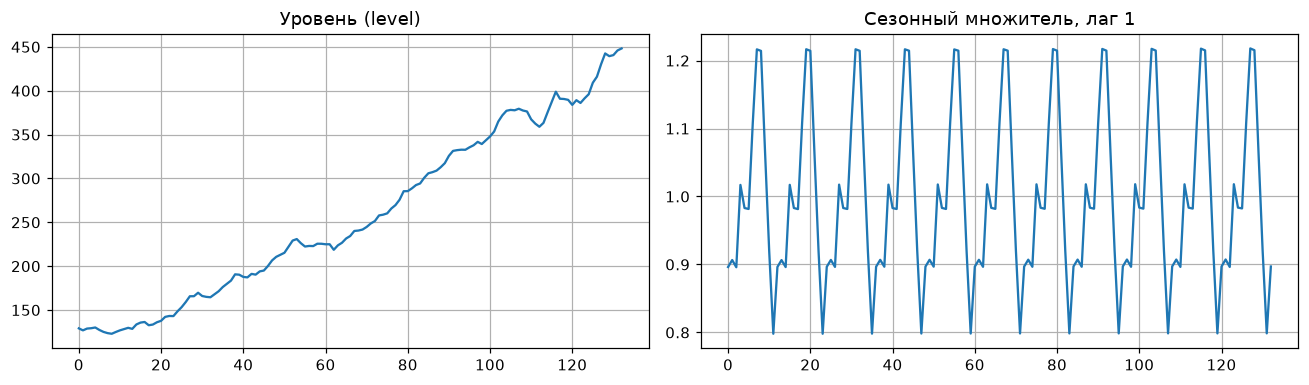

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(states["level"].values)
axes[0].set_title("Уровень (level)")
axes[1].plot(states["season_lag_1"].values)
axes[1].set_title("Сезонный множитель, лаг 1")
plt.tight_layout()
plt.show()

## 1.4. Диагностика остатков

`fitted` — предсказания модели «в прошлое» (in-sample), `residuals` — то, что
использует внутренний оптимизатор (для мультипликативной ошибки это не то же
самое, что `y - fitted`!), а `actual_residuals` — обычные остатки `y - fitted`
в исходном масштабе. Для содержательной диагностики нужны именно последние.

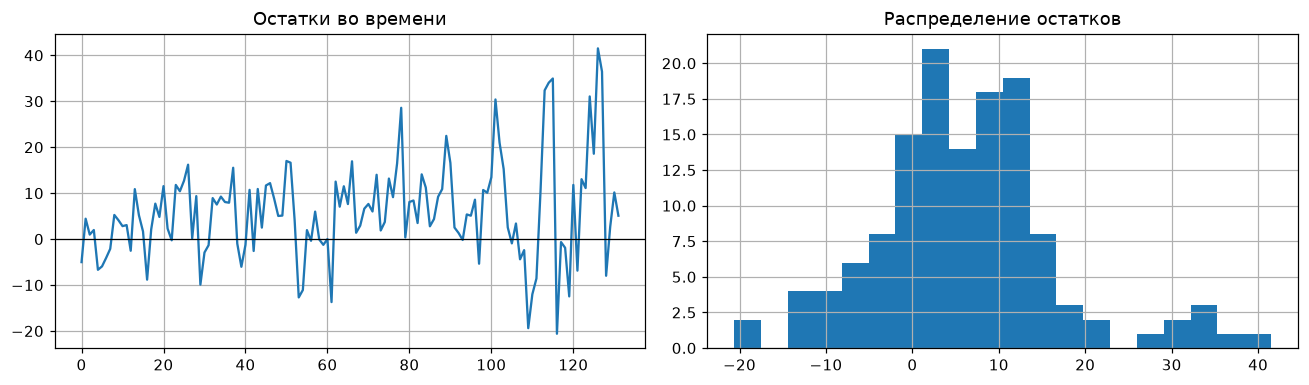

Среднее остатков: 6.042 (должно быть близко к 0)


In [27]:
resid = m["actual_residuals"]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(resid)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Остатки во времени")
axes[1].hist(resid, bins=20)
axes[1].set_title("Распределение остатков")
plt.tight_layout()
plt.show()

print("Среднее остатков:", round(np.nanmean(resid), 3), "(должно быть близко к 0)")

## 1.5. Сравнение моделей: AICc внутри библиотеки, ошибка — на тесте


In [32]:
aicc_table = pd.Series(
    {
        #"SES": sf.fitted_[0, 0].model_["aicc"],
        "Holt": sf.fitted_[0, 1].model_["aicc"],
        "HoltWinters": sf.fitted_[0, 2].model_["aicc"],
        "AutoETS": sf.fitted_[0, 3].model_["aicc"],
    },
    name="aicc",
).sort_values()
print("AICc (меньше — лучше):")
print(aicc_table.round(1))

AICc (меньше — лучше):
AutoETS        1297.5
HoltWinters    1409.6
Holt           1562.7
Name: aicc, dtype: float64


In [33]:
scored = forecast.merge(air_test, on=["unique_id", "ds"])
metrics = evaluate(
    scored, metrics=[mae, rmse, mape], models=["SES", "Holt", "HoltWinters", "AutoETS"]
)
metrics

,unique_id,metric,SES,Holt,HoltWinters,AutoETS
0,AirPassengers,mae,76.283630,66.356341,23.490143,35.612475
1,AirPassengers,rmse,103.271016,92.713338,26.228497,40.083621
2,AirPassengers,mape,0.143064,0.124271,0.048133,0.072068


---
# 2. Доверительные интервалы

Для моделей семейства ETS есть замкнутые формулы дисперсии прогноза, и `statsforecast` считает по ним интервалы
автоматически — достаточно передать `level` в `forecast`/`predict`.

In [34]:
sf_levels = StatsForecast(models=[AutoETS(season_length=12, alias="AutoETS")], freq="MS", n_jobs=1)
fcst_levels = sf_levels.forecast(df=air_train, h=h, level=[80, 95])
fcst_levels

,unique_id,ds,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95
0,AirPassengers,1960-01-01,406.651276,369.120850,382.111450,431.191101,444.181671
1,AirPassengers,1960-02-01,401.732910,361.186188,375.220825,428.244965,442.279633
2,AirPassengers,1960-03-01,456.289642,412.153900,427.430817,485.148438,500.425354
3,AirPassengers,1960-04-01,440.870514,393.628571,409.980652,471.760376,488.112488
4,AirPassengers,1960-05-01,440.333923,390.183533,407.542358,473.125488,490.484283
5,AirPassengers,1960-06-01,496.866058,443.239075,461.801239,531.930847,550.493042
6,AirPassengers,1960-07-01,545.839111,488.293945,508.212341,583.465820,603.384216
7,AirPassengers,1960-08-01,544.672485,483.473389,504.656555,584.688477,605.871643
8,AirPassengers,1960-09-01,477.034485,413.173065,435.277740,518.791199,540.895935
9,AirPassengers,1960-10-01,412.423096,346.641357,369.410736,455.435486,478.204865


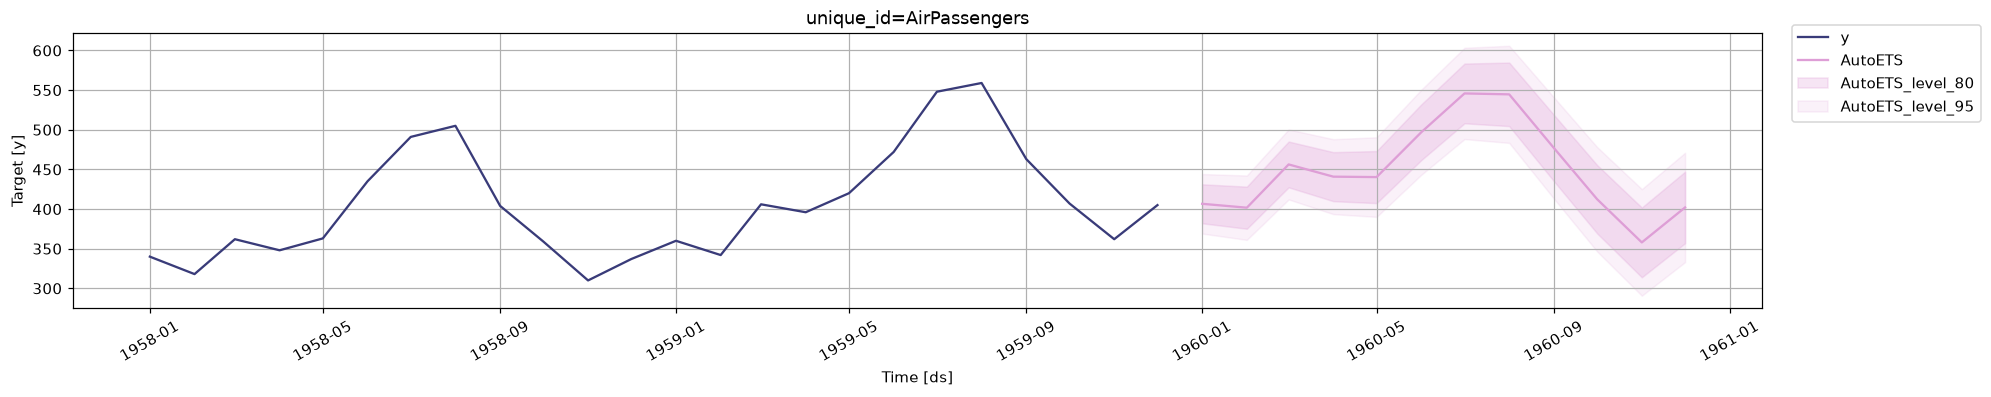

In [35]:
StatsForecast.plot(df=air_train, forecasts_df=fcst_levels, level=[80, 95], max_insample_length=24)

---
# 3. Чем это отличается от `statsmodels`, и что даёт масштаб

## 3.1. Концептуальные различия

| | `statsmodels` (`ETSModel`) | `statsforecast` (`AutoETS`) |
|---|---|---|
| Единица работы | один ряд | таблица из любого числа рядов |
| Автоподбор спецификации | нет, только ручной перебор (см. ноутбук `02`) | встроен (`model='ZZZ'`) |
| Отчёт об обучении | `.summary()`, объект `results` | словарь `model_` |
| Реализация | Python/`statespace`, оптимизация scipy | компилируется в машинный код (Numba) |
| Доверительные интервалы | аналитические + `simulate()` | аналитические + конформные |
| Кросс-валидация | пишете вручную | `sf.cross_validation(...)` из коробки |
| Параллелизм по рядам | нет (нужен свой цикл + `multiprocessing`) | параметр `n_jobs` |

## 3.2. Sanity-check: это вообще та же модель?

Прежде чем сравнивать скорость, убедимся, что сравниваем сопоставимые вещи:
зададим `statsmodels` ту же спецификацию, что выбрал `AutoETS`, и сравним прогнозы.

In [36]:
error, trend, season, damped = chosen["components"]
type_map = {"A": "add", "M": "mul", "N": None}

sm_res = ETSModel(
    air_train.set_index("ds")["y"].asfreq("MS"),
    error=type_map[error],
    trend=type_map[trend],
    seasonal=type_map[season],
    seasonal_periods=12,
).fit(disp=False)

sf_only_ets = StatsForecast(
    models=[AutoETS(season_length=12, alias="AutoETS")], freq="MS", n_jobs=1
)
fc_sf = sf_only_ets.forecast(df=air_train, h=h)["AutoETS"].to_numpy()
fc_sm = sm_res.forecast(h).to_numpy()

compare = pd.DataFrame({"ds": air_test["ds"].values, "statsforecast": fc_sf, "statsmodels": fc_sm})
compare["abs_diff"] = (compare["statsforecast"] - compare["statsmodels"]).abs()
compare

,ds,statsforecast,statsmodels,abs_diff
0,1960-01-01,406.651276,410.049652,3.398376
1,1960-02-01,401.732910,404.225390,2.492480
2,1960-03-01,456.289642,463.458818,7.169175
3,1960-04-01,440.870514,444.249835,3.379321
4,1960-05-01,440.333923,443.092258,2.758334
5,1960-06-01,496.866058,501.761093,4.895034
6,1960-07-01,545.839111,554.613804,8.774692
7,1960-08-01,544.672485,550.602850,5.930365
8,1960-09-01,477.034485,478.883217,1.848733
9,1960-10-01,412.423096,415.455086,3.031990


Прогнозы почти совпадают (расхождение — доли процента от масштаба ряда), хотя
не идентичны бит-в-бит: у библиотек разные оптимизаторы и инициализация
параметров


## 3.3. Замер скорости на масштабе: 2000 рядов

Возьмём `Monthly_sample.csv` — 2000 месячных рядов длиной 76 наблюдений каждый
(в широком формате: одна колонка на ряд) — и превратим их в длинный формат.

In [37]:
wide = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/data/Monthly_sample.csv",
    index_col=0,
)
wide.index = pd.date_range("2000-01-01", periods=len(wide), freq="MS")

many_series = (
    wide.reset_index(names="ds")
    .melt(id_vars="ds", var_name="unique_id", value_name="y")[["unique_id", "ds", "y"]]
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)
print("Рядов:", many_series["unique_id"].nunique(), "| наблюдений всего:", len(many_series))
many_series.head()

Рядов: 2000 | наблюдений всего: 154000


,unique_id,ds,y
0,col_0,2000-01-01,2834.0
1,col_0,2000-02-01,2821.0
2,col_0,2000-03-01,2852.0
3,col_0,2000-04-01,2920.0
4,col_0,2000-05-01,2980.0


Сначала — «прогрев»: при первом вызове Numba компилирует функции в машинный код,
и это время не имеет отношения к скорости самих вычислений.

In [38]:
sf_bench = StatsForecast(
    models=[AutoETS(model="AAA", season_length=12, alias="AutoETS")], freq="MS", n_jobs=1
)
_ = sf_bench.forecast(df=many_series[many_series["unique_id"] == "col_0"], h=12)  # прогрев JIT

In [39]:
sf_sizes = [50, 100, 200, 500, 1000, 2000]
sf_times = []
for n in sf_sizes:
    ids = [f"col_{i}" for i in range(n)]
    subset = many_series[many_series["unique_id"].isin(ids)]
    t0 = time.time()
    sf_bench.forecast(df=subset, h=12)
    sf_times.append(time.time() - t0)
    print(f"statsforecast, {n:>4} рядов: {sf_times[-1]:6.2f} с")

statsforecast,   50 рядов:   0.38 с
statsforecast,  100 рядов:   0.76 с
statsforecast,  200 рядов:   1.39 с
statsforecast,  500 рядов:   3.53 с
statsforecast, 1000 рядов:   6.96 с
statsforecast, 2000 рядов:  14.00 с


Для `statsmodels` честный цикл `for` по рядам на 2000 рядах займёт слишком много
времени внутри учебного занятия — измерим его на 50/100/200 рядах напрямую,
а на большее число экстраполируем линейно (у ETS время на один ряд практически
постоянно, поэтому линейная оценка здесь корректна).

In [40]:
sm_measured_sizes = [50, 100, 200]
sm_times = []
for n in sm_measured_sizes:
    t0 = time.time()
    for i in range(n):
        y = many_series.loc[many_series["unique_id"] == f"col_{i}"].set_index("ds")["y"]
        y = y.asfreq("MS")
        ETSModel(y, error="add", trend="add", seasonal="add", seasonal_periods=12).fit(disp=False)
    sm_times.append(time.time() - t0)
    print(f"statsmodels,   {n:>4} рядов: {sm_times[-1]:6.2f} с")

sm_ms_per_series = np.mean([t / n for t, n in zip(sm_times, sm_measured_sizes)])
print(f"\nВ среднем statsmodels тратит {sm_ms_per_series * 1000:.1f} мс на один ряд.")

statsmodels,     50 рядов:   3.34 с
statsmodels,    100 рядов:   6.84 с
statsmodels,    200 рядов:  12.97 с

В среднем statsmodels тратит 66.7 мс на один ряд.


In [41]:
benchmark = pd.DataFrame(
    {
        "n_рядов": sf_sizes,
        "statsforecast, с": sf_times,
        "statsmodels, с (экстраполяция по мс/ряд)": [sm_ms_per_series * n for n in sf_sizes],
    }
)
benchmark["ускорение, ×"] = (
    benchmark["statsmodels, с (экстраполяция по мс/ряд)"] / benchmark["statsforecast, с"]
)
benchmark.round(2)

,n_рядов,"statsforecast, с","statsmodels, с (экстраполяция по мс/ряд)","ускорение, ×"
0,50,0.38,3.33,8.71
1,100,0.76,6.67,8.78
2,200,1.39,13.33,9.56
3,500,3.53,33.34,9.45
4,1000,6.96,66.67,9.58
5,2000,14.00,133.35,9.52


🔍 На больших масштабах также может быть полезно включать мультипроцессинг (**n_jobs** > 1)


---
# Итоги

## Что важно запомнить

1. **В `statsforecast` нет одного класса ETS.** Есть лестница от ручных
   `SimpleExponentialSmoothing` до полностью автоматического `AutoETS(model='ZZZ')`.
   Буквы E/T/S принимают значения `A`/`M`/`N`/`Z`, и `Z` — это не «нет компоненты»,
   а «подбери сам».
2. **После обучения нет `summary()`** — есть словарь `model_` с `method`, `par`,
   `states`, `aic`/`aicc`/`bic`, `residuals`. Функция `ets_report()` выше — то,
   что стоит унести с собой, чтобы не собирать эти поля каждый раз заново.
3. **AIC/AICc сравним только внутри одной библиотеки.** Между `statsmodels` и
   `statsforecast` сравнивайте прогноз на отложенном тесте, а не критерий.
4. **Главный выигрыш `statsforecast` — не в одном ряде, а в масштабе**: даже без
   параллелизма (`n_jobs=1`) компилируемая реализация оказывается быстрее на ряд,
   а с `n_jobs=-1` к этому добавляется ещё и распараллеливание по ядрам.
